# SHRED on ME4OH full-field OFAM3 SST data - Changing numbers of sensors

Experiment 2.5: changing number of sensors and comparing metrics

Note: Run training and evaluating halves of shred_ofam3sst_static_changing_sensor_nums.py script first

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
with open("Reconstructions/change_num_sensors/v2/eval_metric_results.json", 'r') as f:
    data = json.load(f)

In [3]:
# Unpack data dict into NA and GS dataframes
na_df = pd.DataFrame([data[key]['NA'] for key in sorted(data.keys(), key=lambda x: int(x))], 
                      index=[int(key) for key in sorted(data.keys(), key=lambda x: int(x))])
gs_df = pd.DataFrame([data[key]['GS'] for key in sorted(data.keys(), key=lambda x: int(x))], 
                      index=[int(key) for key in sorted(data.keys(), key=lambda x: int(x))])

In [4]:
colours = {  # IBM colourblind palette
    "RMSE": "#1589e8",
    "MAE": "#dc267f",
    "R2": "#631ff3",
    "Average SSI": "#fe5100",
    "Average all time diff": "#ffb000"
}

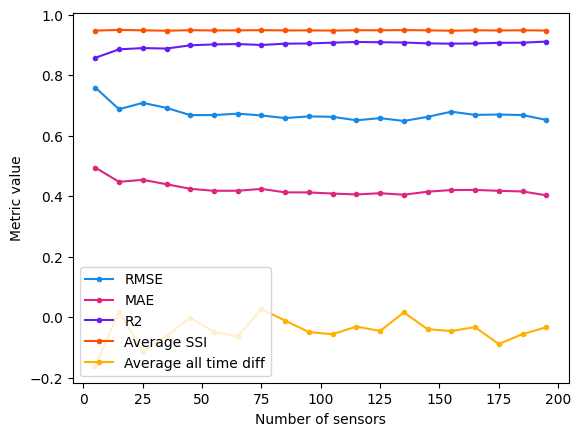

In [6]:
for col in na_df.columns:
    plt.plot(na_df.index, na_df[col], label=col, c=colours[col], marker='.')
plt.xlabel("Number of sensors")
plt.ylabel("Metric value")
plt.legend()

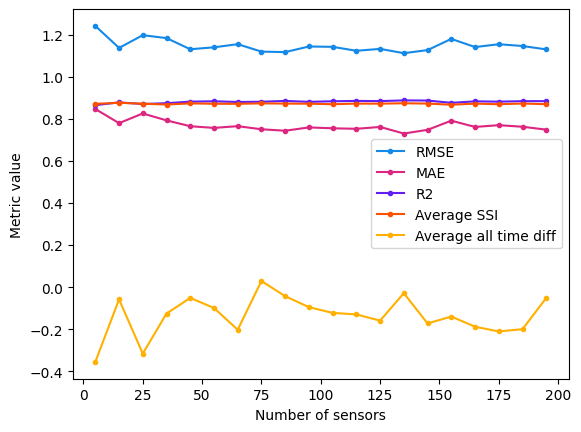

In [7]:
for col in gs_df.columns:
    plt.plot(gs_df.index, gs_df[col], label=col, c=colours[col], marker='.')
plt.xlabel("Number of sensors")
plt.ylabel("Metric value")
plt.legend()

In [8]:
# data, dates, lats, longs = load_files()

# for num_sensors in na_df.index:
#     sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
#     sensor_coords=(longs[sensor_locations], lats[sensor_locations])
#     plot_sensors(sensor_coords)